In [ ]:
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import cv2  
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path

ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

In [3]:
python --version

NameError: name 'python' is not defined

In [16]:
#  Add project root to sys.path for local imports
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [19]:
# Import local modules
from src.configs.settings import settings

In [3]:
ocr = PaddleOCR(use_angle_cls=True, lang='en')

[2026/05/12 10:22:04] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/samuel/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/samuel/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_ch

In [7]:
def paddle_ocr(image):
    result = ocr.ocr(image, det=False, rec=True, cls=False)

    text, confidence = result[0][0]

    return text, confidence

In [10]:
result = paddle_ocr('/home/samuel/Downloads/vision-based-access-intelligence/data/license_recognition/inputs/val/ABC27CF.jpg')
print(result)

('ABC-27CF', 0.9313557147979736)


In [ ]:
# # for every image in train and validation directory, if first characters of filename are letters, rename images to the format "ABC-1234.jpg" where ABC are the first three letters of the filename and 1234 are the remaining characters in the filename.
# import re

# def rename_images(image_folder):
#     image_folder = Path(image_folder).resolve()
    
#     if not image_folder.exists():
#         print(f"✗ Directory not found: {image_folder}")
#         return
    
#     jpg_files = sorted(list(image_folder.glob("*.jpg")) + list(image_folder.glob("*.JPG")))
    
#     if not jpg_files:
#         print(f"✗ No JPG files found in: {image_folder}")
#         return
    
#     for img_path in jpg_files:
#         filename = img_path.stem
#         extension = img_path.suffix

#         # Only rename if the first 3 chars are letters and the 4th char is not already a hyphen
#         match = re.match(r"^([A-Za-z]{3})(?!-)(.+)$", filename)
#         if match:
#             prefix = match.group(1).upper()
#             suffix = match.group(2)
#             new_filename = f"{prefix}-{suffix}"
#             if filename != new_filename:
#                 new_path = img_path.parent / f"{new_filename}{extension}"
#                 img_path.rename(new_path)
#                 print(f"Renamed: {img_path.name} -> {new_path.name}")

# rename_images(VAL_DIR)

In [25]:
# Data Configs
INPUT_DIR = settings.LICENSE_INPUT_DIR 
TRAIN_DIR = INPUT_DIR / "train"
VAL_DIR = INPUT_DIR / "val"
OUTPUT_DIR = settings.LICENSE_OUTPUT_DIR

In [26]:
# Benchmarking Function
def benchmark_plates(image_folder):
    results = []
    image_folder = Path(image_folder).resolve()
    
    if not image_folder.exists():
        print(f"✗ Directory not found: {image_folder}")
        return pd.DataFrame()
    
    # Find all jpg files
    jpg_files = sorted(list(image_folder.glob("*.jpg")) + list(image_folder.glob("*.JPG")))
    
    if not jpg_files:
        print(f"✗ No JPG files found in: {image_folder}")
        return pd.DataFrame()
    
    print(f"Found {len(jpg_files)} images to process...")
    
    # Iterate through all images in the folder
    for idx, img_path in enumerate(jpg_files):
        if (idx + 1) % 20 == 0:
            print(f"  Processing: {idx + 1}/{len(jpg_files)}")
        
        # Ground truth is the filename (e.g., '0211DBO')
        ground_truth = img_path.stem.upper()
        
        try:
            # Run OCR using legacy method
            # This calls predict() internally but handles parameters better
            result = ocr.ocr(str(img_path))
            
            # PaddleOCR returns a list of detected text regions
            # Format: [ [box, (text, confidence)], [...] ]
            predicted_text = ""
            confidence = 0.0
            
            if result and len(result) > 0 and result[0]:
                # Take the first detection (usually the most prominent text on a plate crop)
                first_detection = result[0][0]
                if len(first_detection) >= 2:
                    text_info = first_detection[1]
                    if isinstance(text_info, (tuple, list)) and len(text_info) >= 2:
                        predicted_text = str(text_info[0]).replace(" ", "").upper()
                        confidence = float(text_info[1])
            
            # Basic Accuracy Logic
            is_match = (predicted_text == ground_truth)
            
            results.append({
                "filename": img_path.name,
                "ground_truth": ground_truth,
                "prediction": predicted_text,
                "confidence": round(confidence, 4),
                "match": is_match
            })
        except Exception as e:
            # Silently skip errors for now
            results.append({
                "filename": img_path.name,
                "ground_truth": ground_truth,
                "prediction": "",
                "confidence": 0,
                "match": False
            })
    
    df = pd.DataFrame(results)
    print(f"✓ Processed {len(df)} images")
    return df

In [27]:
# Run the benchmark
print("\nStarting license plate OCR benchmark...")
result_df = benchmark_plates(VAL_DIR)
print(result_df.head())


Starting license plate OCR benchmark...
Found 128 images to process...
[2026/05/12 10:47:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.007517814636230469
[2026/05/12 10:47:41] ppocr DEBUG: cls num  : 1, elapsed : 0.0024073123931884766
[2026/05/12 10:47:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.015498876571655273
[2026/05/12 10:47:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.006481170654296875
[2026/05/12 10:47:41] ppocr DEBUG: cls num  : 1, elapsed : 0.0022573471069335938
[2026/05/12 10:47:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.015457630157470703
[2026/05/12 10:47:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.006331443786621094
[2026/05/12 10:47:41] ppocr DEBUG: cls num  : 1, elapsed : 0.002240419387817383
[2026/05/12 10:47:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.015790939331054688
[2026/05/12 10:47:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.0066988468170166016
[2026/05/12 10:47:41] ppocr DEBUG: cls num  : 1, elapsed : 0.002286672592163086
[2026/05/12 10:47

In [28]:
result_df.head()

,filename,ground_truth,prediction,confidence,match
0,AAA-912GT.jpg,AAA-912GT,AAA-912GT,0.9587,True
1,ABC-101KP.jpg,ABC-101KP,ABC-101KP,0.9147,True
2,ABC-188CV.jpg,ABC-188CV,ABC-188CV,0.9125,True
3,ABC-27CF.jpg,ABC-27CF,ABC-27CF,0.9200,True
4,ABC-544RP.jpg,ABC-544RP,AB0-544RP,0.8499,False


In [39]:
result_df

,filename,ground_truth,prediction,confidence,match
0,AAA-912GT.jpg,AAA-912GT,AAA-912GT,0.9587,True
1,ABC-101KP.jpg,ABC-101KP,ABC-101KP,0.9147,True
2,ABC-188CV.jpg,ABC-188CV,ABC-188CV,0.9125,True
3,ABC-27CF.jpg,ABC-27CF,ABC-27CF,0.9200,True
4,ABC-544RP.jpg,ABC-544RP,AB0-544RP,0.8499,False
...,...,...,...,...,...
123,YAB-777DN.jpg,YAB-777DN,YA8-7770N,0.6681,False
124,YAB-777NK.jpg,YAB-777NK,YAB-777NK,0.9323,True
125,YAB-866CB.jpg,YAB-866CB,YAB-866CB,0.9544,True
126,YAB-982AX.jpg,YAB-982AX,YAB-982AX,0.9214,True


In [29]:
# Get accuracy metrics
accuracy = result_df['match'].mean()
print(f"\nOverall OCR Accuracy: {accuracy:.2%}")


Overall OCR Accuracy: 65.62%



Sample of 10 Incorrect Predictions:


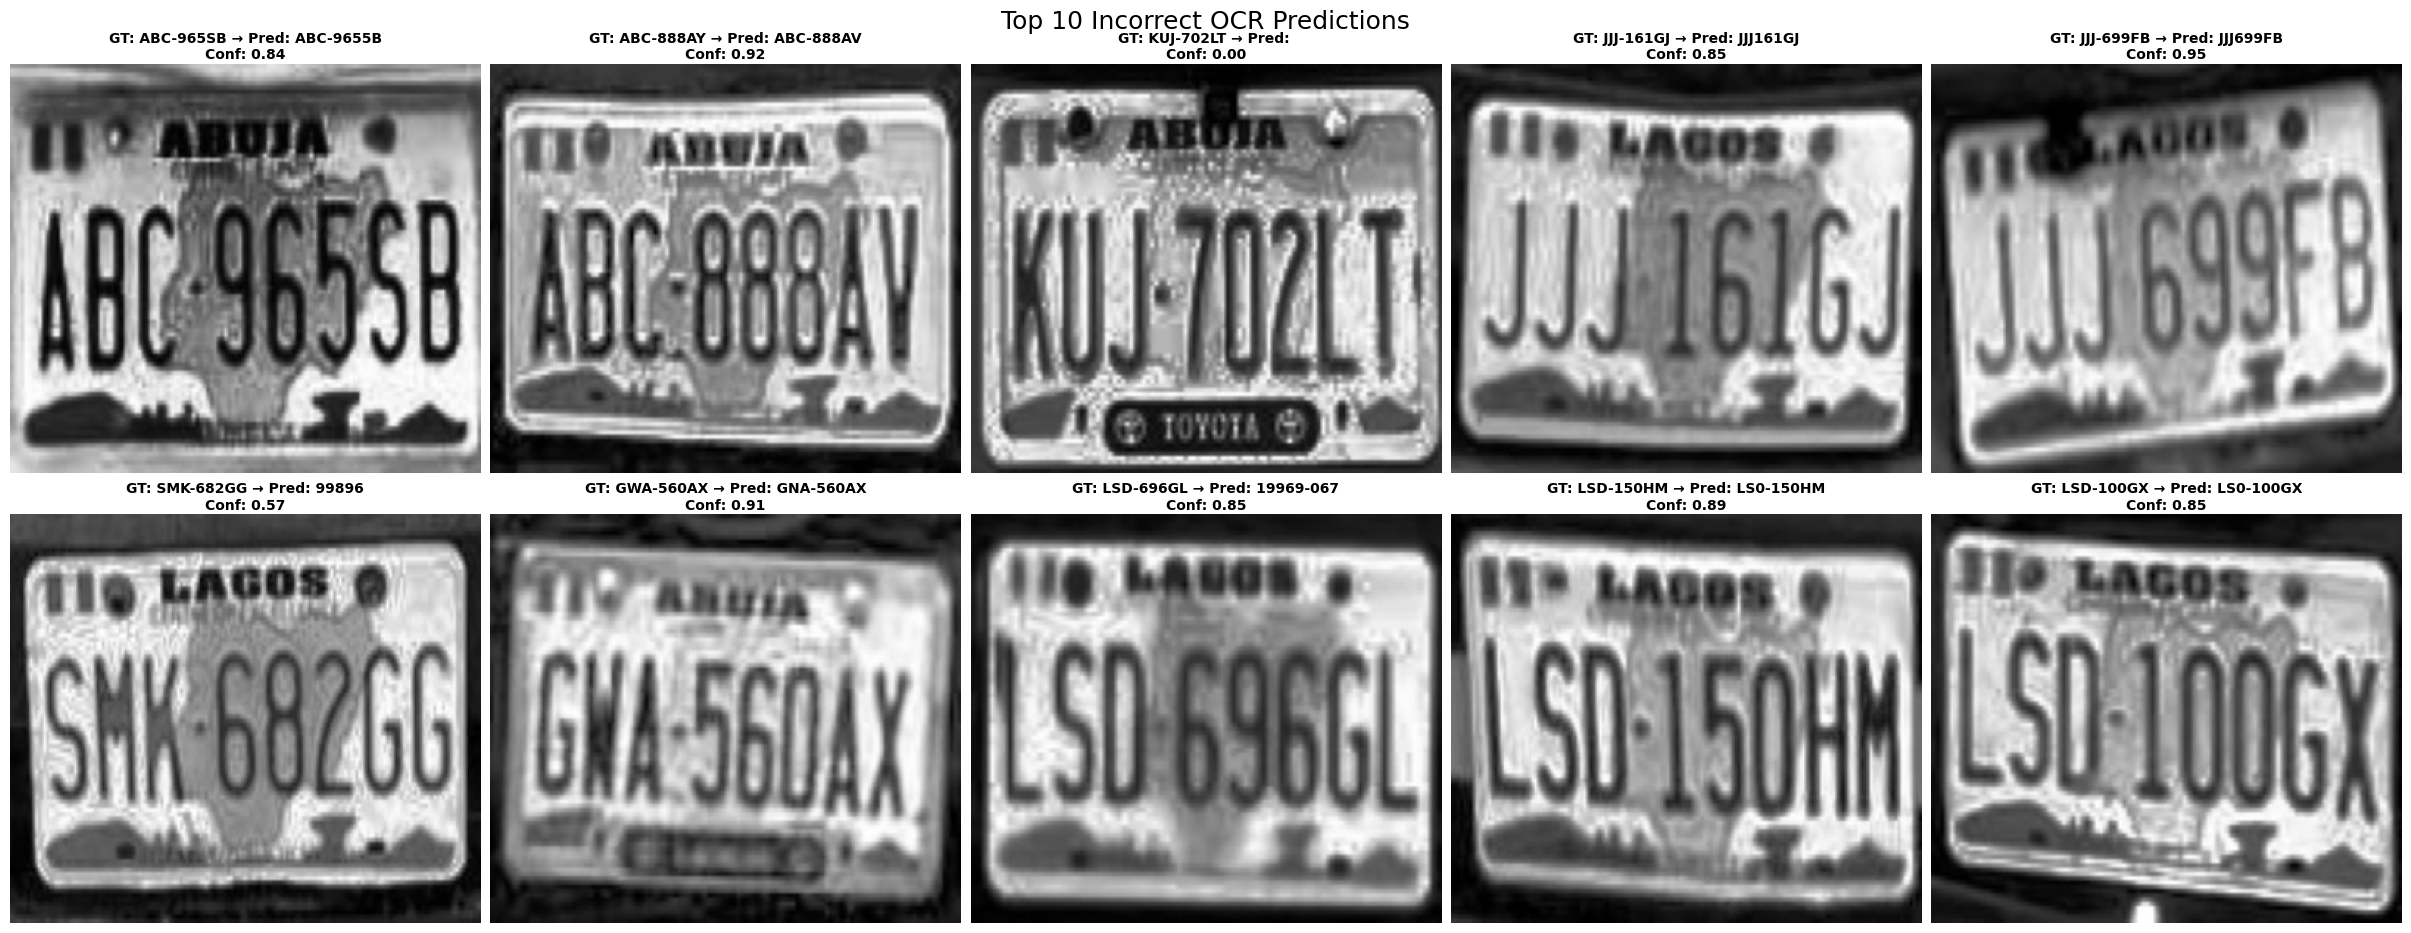

In [38]:
# Display 10 random samples of incorrect predictions with a cleaner layout
incorrect_samples = result_df[result_df['match'] == False]

if incorrect_samples.empty:
    print("No incorrect predictions to display.")
else:
    sample_count = min(10, len(incorrect_samples))
    incorrect_samples = incorrect_samples.sample(sample_count, random_state=1).reset_index(drop=True)

    print(f"\nSample of {sample_count} Incorrect Predictions:")
    fig, axes = plt.subplots(2, 5, figsize=(24, 9), constrained_layout=True)
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, incorrect_samples.iterrows()):
        img_path = VAL_DIR / row['filename']
        img = cv2.imread(str(img_path))
        if img is None:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb, aspect='auto')
        ax.set_title(
            f"GT: {row['ground_truth']} → Pred: {row['prediction']}\nConf: {row['confidence']:.2f}",
            fontsize=10,
            pad=4,
            fontweight='bold'
        )
        ax.axis('off')

    for ax in axes[sample_count:]:
        ax.axis('off')

    fig.suptitle('Top 10 Incorrect OCR Predictions', fontsize=18, y=1.02)
    fig.subplots_adjust(top=0.92, hspace=0.28, wspace=0.12)
    plt.show()